# Real Euclid images versus position-matched MER photometry

This notebook measures the actual public Euclid Q1 VIS/Y/J/H mosaics in **70 real-image scene regions, including 30 additional spatially separated patch IDs excluded from the existing train, validation and test splits** and compares each flux with its position-matched MER catalog reference. It includes three measurements on common sources and masks:

- The linked package’s actual upstream workflow: SEP blob detection/model selection on VIS, with Tractor’s profile ladder and archive GRID-PSFs, followed by its native forced-flux measurement in each band.
- JAISP’s mixture photometer using a raw-VIS image prior.
- The same mixture photometer using its frozen foundation prior.

Real VIS references use `flux_vis_sersic`; the extended-source MER NISP cross-check uses `flux_{y,j,h}_templfit` (the same reference choice made in the source notebook). These MER products are real pipeline catalog measurements, **not independent truth**. We therefore call the vertical axis measured-minus-MER offset. The model fits and MER fluxes are both in μJy before AB conversion.

The comparison uses the identical downloaded image cutouts, variance maps, pixel masks, archive PSF fields, and source list. Tractor runs the unmodified upstream SEP source selection and position refinement. The mixture measurements use Tractor’s refined positions as well. All 629 MER-matched sources are retained in the comparison table. The magnitude plot shows each source with positive fitted flux for that method; zero or negative fits remain in the table because AB magnitude offsets are undefined for them. The main plot includes all source-quality flags and edge positions, with the clean subset available in the summary.

The real image/PSF caches and local MER catalog are under `runs/real_mer/`. See the region manifests for archive tile IDs, image zero points and PSF paths.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'models/photometry/self_supervised').is_dir())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
OUT=ROOT/'models/photometry/self_supervised/runs/real_mer'


## Match real fluxes and make the plots

The local catalogs are matched by MER object ID after the original sky coordinates place MER sources onto each native image. This cell checks exact source/band/model coverage, keeps the archived MAGZERO conversion, and writes the per-source comparison, summaries and figures.

In [2]:
from models.photometry.self_supervised.real_mer_report import collect,summarize,make_plots
import os
os.chdir(ROOT)
matched=collect()
summary=summarize(matched)
figures=make_plots(matched)
print(f"Real MER sources: {matched.object_id.nunique()} | regions: {matched.region.nunique()} | source/band/method rows: {len(matched)}")
print('Total MER-matched sources per band and method:')
display(summary[summary.subset=='all'].pivot(index='band',columns='model',values='n_reference'))
print('Sources with positive fitted flux (plotted AB offsets):')
display(summary[summary.subset=='all'].pivot(index='band',columns='model',values='n'))
print('Median offset using all sources with positive fitted flux:')
display(summary[summary.subset=='all'].pivot(index='band',columns='model',values='median_delta_ab').round(3))
print('Clean-geometry subset for comparison:')
display(summary[summary.subset=='clean'].pivot(index='band',columns='model',values='n'))


Real MER sources: 629 | regions: 70 | source/band/method rows: 10064
Total MER-matched sources per band and method:
Sources with positive fitted flux (plotted AB offsets):
Median offset using all sources with positive fitted flux:
Clean-geometry subset for comparison:


/home/shemmati/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,629,629,629,629
euclid_J,629,629,629,629
euclid_VIS,629,629,629,629
euclid_Y,629,629,629,629


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,612,611,551,609
euclid_J,617,617,571,612
euclid_VIS,624,623,559,624
euclid_Y,614,614,553,609


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,-0.001,-0.023,0.045,0.005
euclid_J,-0.002,-0.016,0.044,0.004
euclid_VIS,-0.052,-0.065,0.012,0.004
euclid_Y,0.000,-0.017,0.068,0.028


model,foundation,image,tractor_jointsky,tractor_upstream
band,,,,
euclid_H,309,309,284,307
euclid_J,314,314,292,310
euclid_VIS,318,318,291,318
euclid_Y,311,311,285,309


## Real-image magnitude offsets

The x-axis is the MER reference AB magnitude, `23.9 − 2.5 log10(flux_uJy)`. The y-axis is measured AB magnitude minus the MER reference magnitude. Faint points show each source; curves are running medians with the central 68% source distribution shaded. The main plot includes all matched sources and all quality flags. A zero or negative fitted flux has no AB offset; those sources stay in the CSV and their counts are shown in the notebook. No simulated pixel data or known injected fluxes enter these measurements.

## Inspect an isolated real-image cutout

The diagnostic tile is selected from regions with the most usable targets and at least 99.5% valid image area in each Euclid band. A displayed target must pass the clean-geometry checks, must not be classified as a star, must lie at least 3 arcsec from masked VIS pixels and any other MER source, and must lie at least 7 arcsec from MER sources brighter than 1 μJy. This avoids masked targets, close blends, and nearby bright objects even when the MER star classifier misses them. The all-source magnitude comparison above still includes all 629 matched sources.

The four panels show the real Euclid VIS/Y/J/H pixels and the isolated MER target positions. The residual panels compare the observed VIS data with the Tractor and foundation model images.

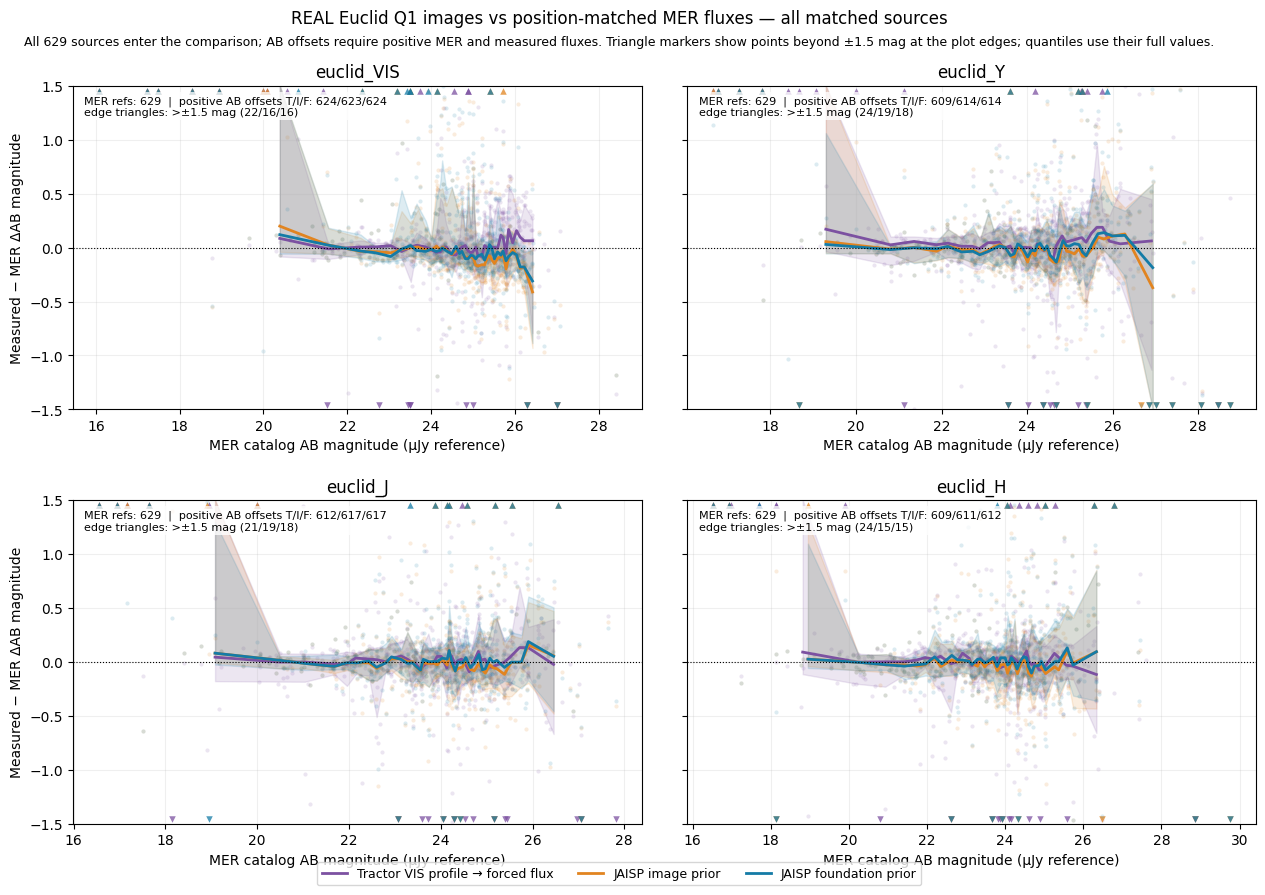

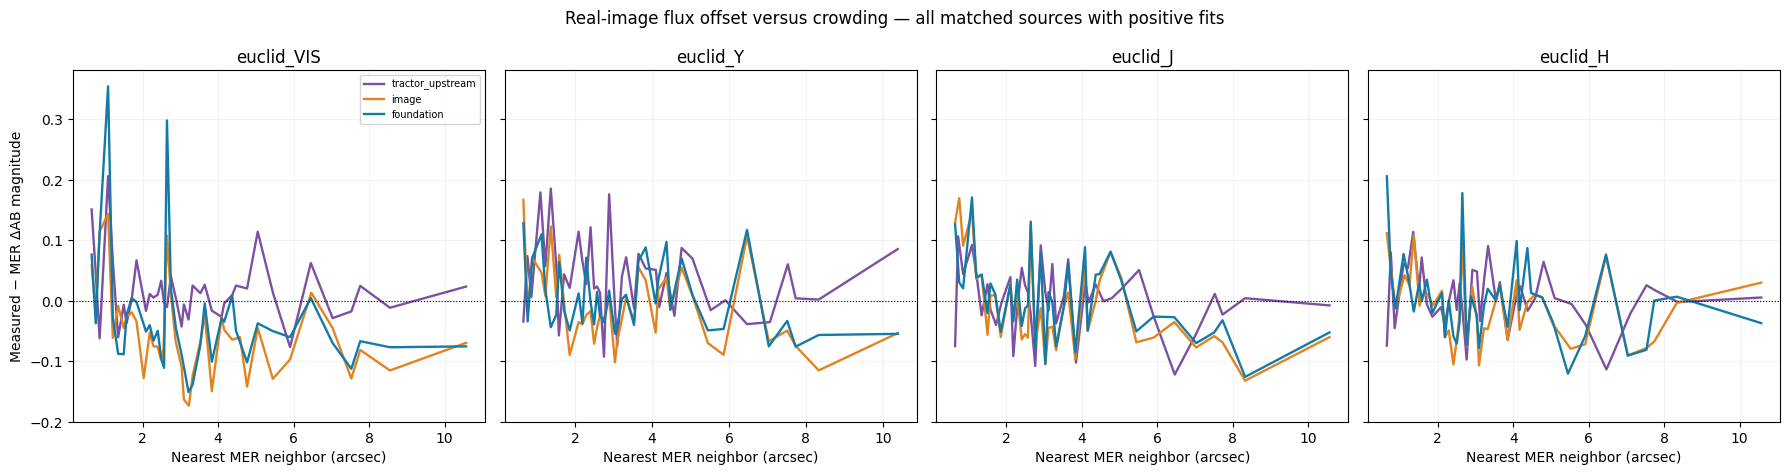

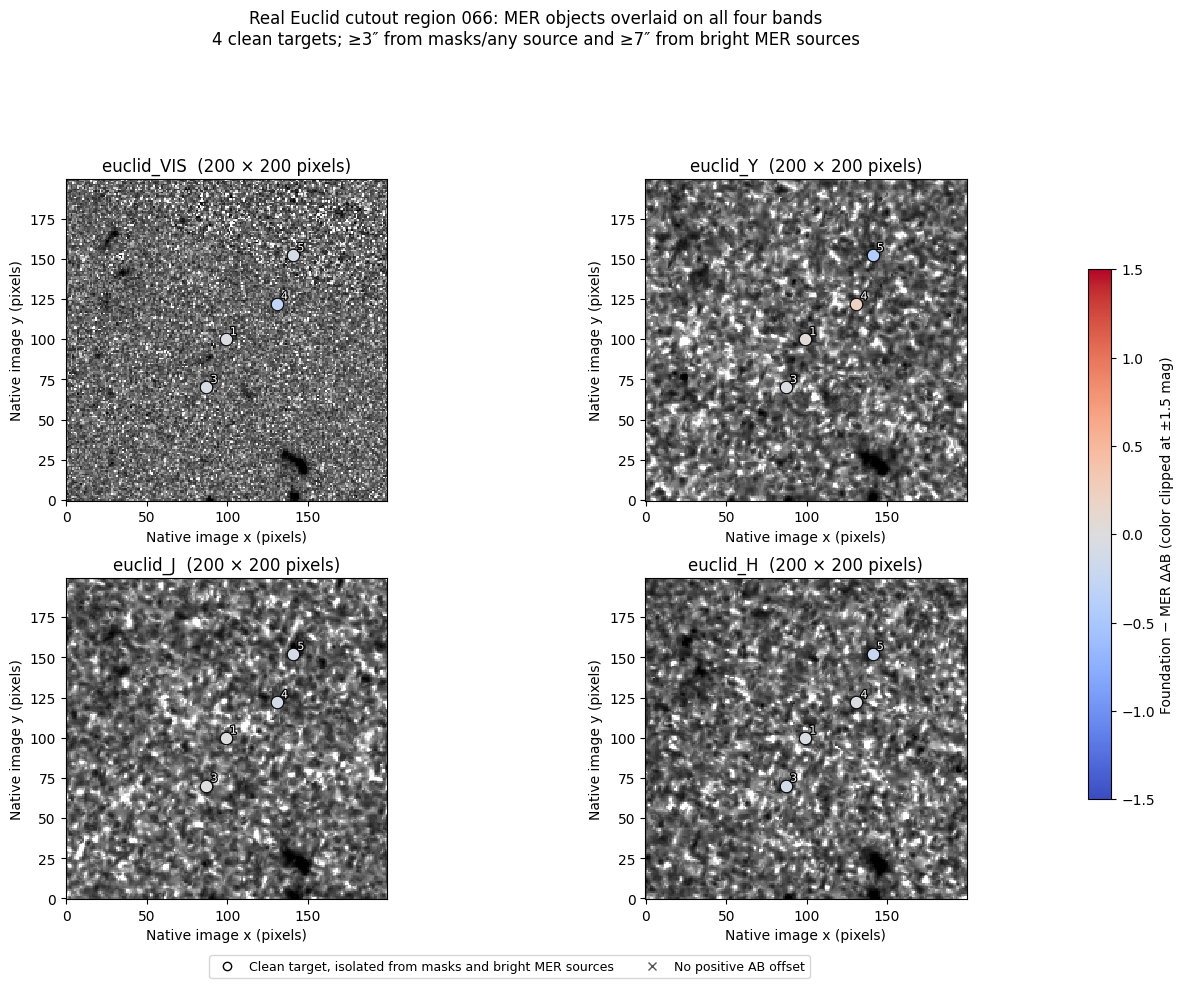

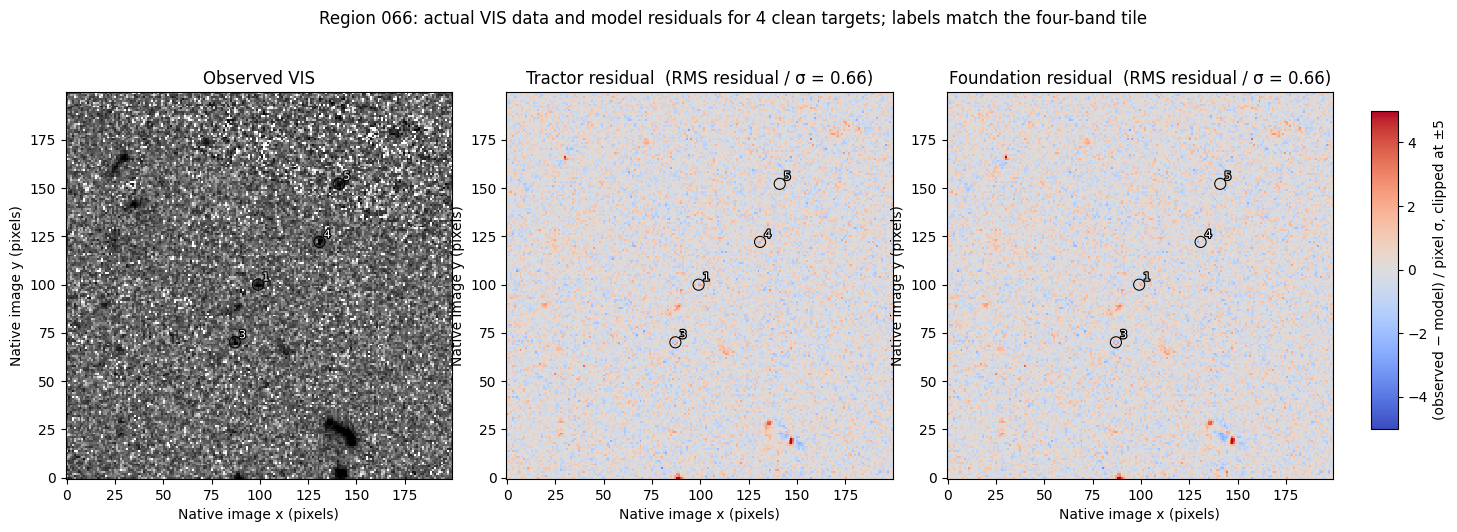

In [3]:
for f in figures:
    display(f);plt.close(f)

## Crowding and source diagnostics

The offset-versus-neighbor-distance plot also uses all matched sources with positive fitted flux. The summary retains clean, isolated and crowded subsets so you can compare those cuts against the full sample. A small MER residual does not establish unbiased flux, since MER fits the same survey products and has its own blend/profile choices.

For the detailed method definitions, per-region Tractor model-selection counts, cached image headers, variances, quality masks and spatial PSF stamps, inspect `runs/real_mer/region_*/`. PSF arrays and source pixels are kept for residual-image inspection.

## Full-tile source alignment check

The detection notebook works on the full 1084 × 1084 VIS tile (108.4 arcsec across), while the forced-photometry scene is a 200 × 200 cutout (20 arcsec). This cell reuses that notebook’s VIS source finder on the same full tile as the selected photometry scene. It overlays every MER source in the tile, the extracted VIS detections, and the MER positions used for forced photometry. The detections are a positional cross-check, not the flux reference.

In [4]:
import json
import numpy as np
from matplotlib.patches import Rectangle
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
from scipy.spatial import cKDTree

for _path in (ROOT / "models", ROOT / "models/detection", ROOT / "models/astrometry2"):
    if str(_path) not in sys.path: sys.path.insert(0, str(_path))
from detection.dataset import _pseudo_labels_vis
from astrometry2.source_matching import safe_header_from_card_string
from models.photometry.self_supervised.real_mer_report import _diagnostic_region

diagnostic_region, local_refs, _, n_safe = _diagnostic_region(matched)
region_dir = OUT / f"region_{diagnostic_region:03d}"
meta = json.loads((region_dir / "metadata.json").read_text())
tile_path = ROOT / "data/euclid_tiles_all_q1" / f"{meta['tile']}_euclid.npz"
with np.load(tile_path, allow_pickle=True) as z:
    vis = np.asarray(z["img_VIS"], dtype=np.float32)
    vis_wcs = WCS(safe_header_from_card_string(z["wcs_VIS"].item()))
h, w = vis.shape
catalog = Table.read(OUT / "mer_catalog.fits")
cat_x, cat_y = vis_wcs.all_world2pix(np.asarray(catalog["ra"], float), np.asarray(catalog["dec"], float), 0)
inside = (cat_x >= 0) & (cat_x < w) & (cat_y >= 0) & (cat_y < h)
mer_xy = np.column_stack((cat_x[inside], cat_y[inside]))
det_norm, _, _, _ = _pseudo_labels_vis(vis, nsig=3.0, max_sources=1000)
det_xy = np.column_stack((det_norm[:, 0] * (w - 1), det_norm[:, 1] * (h - 1)))
nearest, _ = cKDTree(det_xy).query(mer_xy)
print(f"Full tile: {w} × {h} pixels ({w * 0.1:.1f} arcsec square)")
print(f"MER sources: {len(mer_xy)} | VIS detections: {len(det_xy)} | MER within 5 px: {(nearest <= 5).sum()} | median nearest offset: {np.median(nearest):.2f} px")

local_x, local_y = vis_wcs.all_world2pix(local_refs.ra.to_numpy(), local_refs.dec.to_numpy(), 0)
local_xy = np.column_stack((local_x, local_y))
cx, cy = vis_wcs.all_world2pix(meta["ra"], meta["dec"], 0)
x0, y0 = int(np.floor(cx - 100)), int(np.floor(cy - 100))
finite = np.isfinite(vis); vmin, vmax = np.percentile(vis[finite], [1, 99.5])
stretched = np.clip((np.nan_to_num(vis, nan=vmin) - vmin) / max(vmax - vmin, 1e-6), 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(17, 8), constrained_layout=True)
for ax in axes: ax.imshow(stretched, cmap="gray", origin="lower", interpolation="nearest")
axes[0].scatter(det_xy[:, 0], det_xy[:, 1], s=7, c="#13dce0", alpha=.28, linewidths=0, label=f"VIS detections ({len(det_xy)})")
axes[0].scatter(mer_xy[:, 0], mer_xy[:, 1], s=18, facecolors="none", edgecolors="#ffd43b", linewidths=.65, label=f"MER catalog ({len(mer_xy)})")
axes[0].add_patch(Rectangle((x0, y0), 200, 200, fill=False, ec="#ff583e", lw=1.5, label="20″ photometry cutout"))
axes[0].set_xlim(0, w); axes[0].set_ylim(0, h); axes[0].set_title(f"Full VIS tile ({w} × {h} px; {w * .1:.1f}″ square)"); axes[0].legend(loc="upper right", fontsize=8)
axes[1].set_xlim(x0, x0 + 200); axes[1].set_ylim(y0, y0 + 200)
axes[1].scatter(det_xy[:, 0], det_xy[:, 1], s=15, c="#13dce0", alpha=.38, linewidths=0, label="VIS detections")
axes[1].scatter(mer_xy[:, 0], mer_xy[:, 1], s=38, facecolors="none", edgecolors="#ffd43b", linewidths=.8, label="MER catalog")
axes[1].scatter(local_xy[:, 0], local_xy[:, 1], s=46, marker="+", c="#ff3d71", linewidths=1.2, label="Photometry targets")
for i, (xx, yy) in enumerate(local_xy): axes[1].annotate(str(i), (xx, yy), xytext=(3, 3), textcoords="offset points", fontsize=7, color="white")
axes[1].set_title("Same sources, zoomed to the forced-photometry cutout"); axes[1].legend(loc="upper right", fontsize=8)
for ax in axes: ax.set_xlabel("VIS tile x [pixel]"); ax.set_ylabel("VIS tile y [pixel]")
fig.suptitle(f"{meta['tile']}: MER catalog and the detection notebook VIS source finder", fontsize=14)
fig.savefig(OUT / "real_mer_full_tile_sources.png", dpi=160)
plt.show()

Full tile: 1084 × 1084 pixels (108.4 arcsec square)
MER sources: 231 | VIS detections: 417 | MER within 5 px: 201 | median nearest offset: 0.28 px
